# Assignment 1 - SMS Spam Classification
Jugaad Singh Sohal (MDS202421)
## Data Preparation

In this notebook we will prepare the data for spam classification. We need to load the sms data, do some EDA and then split it into train/val/test sets.

### Installing required packages

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
import os
import re
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

### Download the dataset

We are using UCI SMS Spam collection dataset

In [3]:
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip -O data/smsspamcollection.zip z # Download dataset

!unzip -o data/smsspamcollection.zip -d data/ # Extract files

!ls data/ # List files

Prepended http:// to 'z'
Archive:  data/smsspamcollection.zip
  inflating: data/SMSSpamCollection  
  inflating: data/readme             
readme	SMSSpamCollection  smsspamcollection.zip


### Load Data

In [4]:
# loading the data - the file is tab separated
df = pd.read_csv('data/SMSSpamCollection', sep='\t', header=None, names=['label', 'message'], encoding='latin-1')
print(f"Total messages: {len(df)}")
df.head(10)

Total messages: 5572


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


### Exploratory Data Analysis (EDA)

#### Class Distribution (Spam vs Ham)

In [5]:
print(df['label'].value_counts()) # Frequency of ham and spam
print(f"\nSpam percentage: {(df['label'] == 'spam').mean() * 100:.2f}%") # Percentage of spam messages

label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage: 13.41%


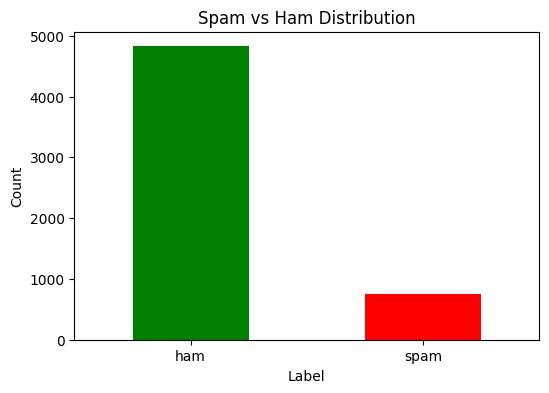

In [6]:
# Histogram of spam vs ham
plt.figure(figsize=(6, 4))
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Message Length Distribution

In [7]:
df['msg_length'] = df['message'].apply(len) # Number of characters in each message
print("Message length stats:")
print(df['msg_length'].describe())

Message length stats:
count    5572.000000
mean       80.616296
std        60.015593
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: msg_length, dtype: float64


#### Message Length Distribution by Class

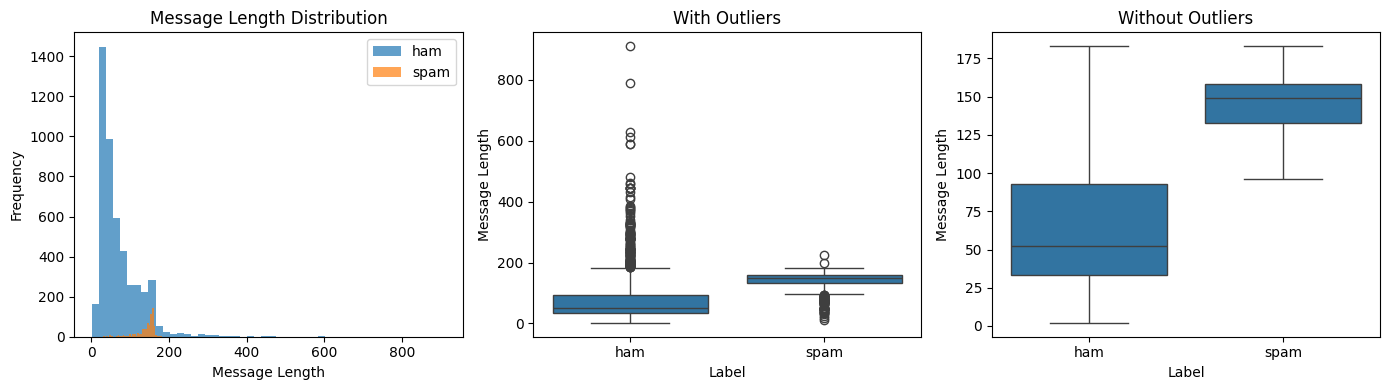


Message length by class:
        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4825.0   71.558964  58.459702   2.0   33.0   52.0   93.0  910.0
spam    747.0  139.119143  28.998900  13.0  133.0  149.0  158.0  224.0


In [8]:
# histogram and boxplot of message lengths by label
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# histogram
axes[0].hist(df[df['label'] == 'ham']['msg_length'], bins=50, alpha=0.7, label='ham')
axes[0].hist(df[df['label'] == 'spam']['msg_length'], bins=50, alpha=0.7, label='spam')
axes[0].set_xlabel('Message Length')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Message Length Distribution')
axes[0].legend()

# boxplot with outliers
sns.boxplot(data=df, x='label', y='msg_length', ax=axes[1])
axes[1].set_title('With Outliers')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Message Length')

# boxplot without outliers
sns.boxplot(data=df, x='label', y='msg_length', ax=axes[2], showfliers=False)
axes[2].set_title('Without Outliers')
axes[2].set_xlabel('Label')
axes[2].set_ylabel('Message Length')

plt.tight_layout()
plt.show()

# distribution stats by class
print("\nMessage length by class:")
print(df.groupby('label')['msg_length'].describe())

#### Frequent Words in Spam vs Ham(Excluding Stopwords)

In [9]:
def get_words(text):
    """Extract words from text after removing stopwords"""
    text = text.lower()
    words = re.findall(r'\b[a-z]+\b', text)
    
    words = [w for w in words if w not in stop_words] # remove stopwords
    
    return words

# get all words from spam messages
spam_words = []
for msg in df[df['label'] == 'spam']['message']:
    spam_words.extend(get_words(msg))

# get all words from ham messages  
ham_words = []
for msg in df[df['label'] == 'ham']['message']:
    ham_words.extend(get_words(msg))

print(f"Total words in spam (after removing stopwords): {len(spam_words)}")
print(f"Total words in ham (after removing stopwords): {len(ham_words)}")

Total words in spam (after removing stopwords): 10396
Total words in ham (after removing stopwords): 38333


In [10]:
# top 20 words in spam and ham
spam_common = Counter(spam_words).most_common(20)
ham_common = Counter(ham_words).most_common(20)

print("Most common words in SPAM:")
for word, count in spam_common:
    print(f"  {word}: {count}")

print("\nMost common words in HAM:")
for word, count in ham_common:
    print(f"  {word}: {count}")

Most common words in SPAM:
  call: 355
  free: 224
  u: 173
  txt: 163
  ur: 144
  mobile: 127
  text: 125
  stop: 123
  claim: 113
  reply: 104
  www: 98
  prize: 93
  get: 86
  cash: 76
  uk: 74
  send: 71
  new: 69
  nokia: 67
  win: 64
  urgent: 63

Most common words in HAM:
  u: 1033
  gt: 318
  lt: 316
  get: 305
  ok: 288
  go: 252
  ur: 247
  call: 238
  know: 237
  good: 235
  like: 234
  got: 233
  come: 230
  day: 212
  love: 205
  time: 202
  going: 169
  one: 168
  home: 165
  want: 165


### Preprocessing

In [11]:
# convert labels to binary - spam=1, ham=0
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

# missing values check
print("Missing values:")
print(df.isnull().sum())

df.head()

Missing values:
label         0
message       0
msg_length    0
label_num     0
dtype: int64


,label,message,msg_length,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",111,0
1,ham,Ok lar... Joking wif u oni...,29,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155,1
3,ham,U dun say so early hor... U c already then say...,49,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",61,0


#### Sample

In [12]:
print("Some HAM messages:")
for msg in df[df['label'] == 'ham']['message'].sample(5, random_state=42):
    print(f"  - {msg[:80]}...")

print("\nSome SPAM messages:")
for msg in df[df['label'] == 'spam']['message'].sample(5, random_state=42):
    print(f"  - {msg[:80]}...")

Some HAM messages:
  - If i not meeting Ã¼ all rite then i'll go home lor. If Ã¼ dun feel like comin it...
  - I.ll always be there, even if its just in spirit. I.ll get a bb soon. Just tryin...
  - Sorry that took so long, omw now...
  - I thk 50 shd be ok he said plus minus 10.. Did Ã¼ leave a line in between paragr...
  - Dunno i juz askin cos i got a card got 20% off 4 a salon called hair sense so i ...

Some SPAM messages:
  - Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get...
  - This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. ...
  - Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to y...
  - Ur cash-balance is currently 500 pounds - to maximize ur cash-in now send GO to ...
  - Last Chance! Claim ur Â£150 worth of discount vouchers today! Text SHOP to 85023...


### Train/Validation/Test Split

Splitting the data into 70% train, 15% validation, 15% test. Using stratified split to keep the same ratio of spam/ham in each set.

In [13]:
# first split into train (70%) and temp (30%)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])

# then split temp into validation (15%) and test (15%)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"Train size: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Validation size: {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test size: {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

Train size: 3900 (70.0%)
Validation size: 836 (15.0%)
Test size: 836 (15.0%)


#### Verify Class Distribution in each set(Stratified Split)

In [14]:
print("Spam percentage in each set:")
print(f"  Train: {(train_df['label'] == 'spam').mean() * 100:.2f}%")
print(f"  Validation: {(val_df['label'] == 'spam').mean() * 100:.2f}%")
print(f"  Test: {(test_df['label'] == 'spam').mean() * 100:.2f}%")

Spam percentage in each set:
  Train: 13.41%
  Validation: 13.40%
  Test: 13.40%


In [16]:
# save to csv
train_df[['label', 'message']].to_csv('data/train.csv', index=False)
val_df[['label', 'message']].to_csv('data/validation.csv', index=False)
test_df[['label', 'message']].to_csv('data/test.csv', index=False)

print("Saved files:")
!ls data/*.csv

Saved files:
data/test.csv  data/train.csv  data/validation.csv
